# CYP2C9 Machine Learning Prediction

PubChem Assay AID: 777

Raw Dataset was downloaded and Incorporated as Raw CSV file for Preprocessing

## 1. Data Curation & Preprocessing

In [98]:
from google.colab import drive
drive.mount('/content/gdrive/', force_remount=True)

Mounted at /content/gdrive/


In [99]:
import pandas as pd
import numpy as np


In [100]:
df = pd.read_csv("AID_777_datatable.csv")
df.head()

/tmp/ipykernel_25057/3224453198.py:1: DtypeWarning: Columns (0,8,9,10,11,12,13,14,15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("AID_777_datatable.csv")


,PUBCHEM_RESULT_TAG,PUBCHEM_SID,PUBCHEM_CID,PUBCHEM_EXT_DATASOURCE_SMILES,PUBCHEM_ACTIVITY_OUTCOME,PUBCHEM_ACTIVITY_SCORE,PUBCHEM_ACTIVITY_URL,PUBCHEM_ASSAYDATA_COMMENT,IC50,Std.Err(IC50),nH,%Inhibition at 5 uM,Mean High,STD Deviation High,Mean Low,STD Deviation Low
0,RESULT_TYPE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,FLOAT,FLOAT,FLOAT,FLOAT,FLOAT,FLOAT,FLOAT,FLOAT
1,RESULT_DESCR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,IC50 value determined using sigmoidal dose res...,Standard Error of IC50 value,Hill coefficient determined using sigmoidal do...,% inhibition of CYP2C9 in primary screening,Mean luminescence signal of negative controls ...,Standard deviation (n=64) of negative controls...,Mean luminescence signal of positive controls ...,Standard deviation (n=64) of positive controls...
2,RESULT_UNIT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,MICROMOLAR,MICROMOLAR,NONE,NONE,CPS,CPS,CPS,CPS
3,1,17406628.0,1218287.0,CCC(=O)NC1=C(C=CC(=C1)C(=O)OCC(=O)C2=CC=CC=C2Cl)C,Inactive,0.0,NaN,NaN,NaN,NaN,NaN,-108.7,65422,10333,297.33,301.88
4,2,17406959.0,6247698.0,CC1=CC=C(C=C1)/C=C/C2=NN=C(O2)C3=CC=C(C=C3)C,Inactive,15.0,NaN,NaN,NaN,NaN,NaN,39.6,65422,10333,297.33,301.88


In [101]:
# Select a single column
print("Compound SMILES:")
print(df["PUBCHEM_EXT_DATASOURCE_SMILES"])


Compound SMILES:
0                                                      NaN
1                                                      NaN
2                                                      NaN
3        CCC(=O)NC1=C(C=CC(=C1)C(=O)OCC(=O)C2=CC=CC=C2Cl)C
4             CC1=CC=C(C=C1)/C=C/C2=NN=C(O2)C3=CC=C(C=C3)C
                               ...                        
95866    C1CN(CCN1CCCNC2=NN3C(=NN=C3C4=CC=CC=C4)C=C2)CC...
95867    COC1=CC(=C(C=C1)NC(=O)C2CCCN2S(=O)(=O)C3=CC=CC...
95868    CC1=CC(=CC(=C1)N(CC(=O)NC2=CC(=CC(=C2)OC)OC)S(...
95869    CN1C=CC=C1CC2=NN=C(N2C3=CC=C(C=C3)F)SCC(=O)NC4...
95870    CCN1C=C(C(=O)C2=C1C=CC(=C2)S(=O)(=O)N(C)C3CCCC...
Name: PUBCHEM_EXT_DATASOURCE_SMILES, Length: 95871, dtype: object


## Select multiple columns (compound, predicted_active, molecular_weight)

In [102]:

df[["PUBCHEM_CID", "PUBCHEM_EXT_DATASOURCE_SMILES", "PUBCHEM_ACTIVITY_OUTCOME", "%Inhibition at 5 uM"]]

,PUBCHEM_CID,PUBCHEM_EXT_DATASOURCE_SMILES,PUBCHEM_ACTIVITY_OUTCOME,%Inhibition at 5 uM
0,NaN,NaN,NaN,FLOAT
1,NaN,NaN,NaN,% inhibition of CYP2C9 in primary screening
2,NaN,NaN,NaN,NONE
3,1218287.0,CCC(=O)NC1=C(C=CC(=C1)C(=O)OCC(=O)C2=CC=CC=C2Cl)C,Inactive,-108.7
4,6247698.0,CC1=CC=C(C=C1)/C=C/C2=NN=C(O2)C3=CC=C(C=C3)C,Inactive,39.6
...,...,...,...,...
95866,5307582.0,C1CN(CCN1CCCNC2=NN3C(=NN=C3C4=CC=CC=C4)C=C2)CC...,Inactive,20.6
95867,5308370.0,COC1=CC(=C(C=C1)NC(=O)C2CCCN2S(=O)(=O)C3=CC=CC...,Active,91.8
95868,5309469.0,CC1=CC(=CC(=C1)N(CC(=O)NC2=CC(=CC(=C2)OC)OC)S(...,Inactive,27.0
95869,5308019.0,CN1C=CC=C1CC2=NN=C(N2C3=CC=C(C=C3)F)SCC(=O)NC4...,Inactive,34.0


Data Cleaning and Normalisation

In [103]:
# Get only the active compounds
# First, clean the DataFrame by dropping metadata rows and converting the relevant column.
# Based on df.head(), rows with NaN in PUBCHEM_CID are metadata rows that need to be excluded.
cleaned_df = df[df["PUBCHEM_CID"].notna()].copy()

# Convert '%Inhibition at 5 uM' to numeric, coercing errors (like 'NONE' or other text) to NaN
cleaned_df["%Inhibition at 5 uM"] = pd.to_numeric(cleaned_df["%Inhibition at 5 uM"], errors='coerce')

# Drop rows where '%Inhibition at 5 uM' is NaN after conversion, as these cannot be used for comparison
cleaned_df = cleaned_df.dropna(subset=["%Inhibition at 5 uM"])

active_df = cleaned_df[cleaned_df["%Inhibition at 5 uM"] > 50]
print(f"Active compounds: {len(active_df)}")
active_df[["PUBCHEM_CID", "PUBCHEM_ACTIVITY_OUTCOME", "PUBCHEM_EXT_DATASOURCE_SMILES","%Inhibition at 5 uM"]]

Active compounds: 18685


,PUBCHEM_CID,PUBCHEM_ACTIVITY_OUTCOME,PUBCHEM_EXT_DATASOURCE_SMILES,%Inhibition at 5 uM
15,11958371.0,Active,CCC(=O)NC(C(=O)OCC)(C(F)(F)F)NC1=C(C=C(C=C1)C(...,54.1
18,6872802.0,Active,CCOC1=C(C=CC(=C1)/C=N/NC(=O)C2=CC(=CC=C2)[N+](...,59.1
23,4687157.0,Active,C1C(C(=O)N(C1=O)CC(C2=CC=CC=C2)C3=CC=CC=C3)SCC...,85.3
32,996925.0,Active,CC1=NN(C(=C1Cl)C(=O)NNC(=S)NC2=CC=CC=C2OC)C,66.1
34,5226271.0,Active,CC1=CC(=CC=C1)NC(=O)C(C)N2C(=O)C3C4CC(C3C2=O)C...,51.6
...,...,...,...,...
95841,5307243.0,Active,C1COC2=C(O1)C=CC(=C2)NC3C4=CC=CC=C4C(=O)N3CC5=...,64.0
95856,5308592.0,Active,CCOC(=O)N1CCC(CC1)N2C(C3=CC=CC=C3C2=O)NC4=CC5=...,81.1
95864,5308655.0,Active,C1CC(N(C1)S(=O)(=O)C2=CC=CC3=C2N=CC=C3)C(=O)N4...,57.6
95867,5308370.0,Active,COC1=CC(=C(C=C1)NC(=O)C2CCCN2S(=O)(=O)C3=CC=CC...,91.8


Create and manuiplate lists for most important columns

In [104]:
molecule_ids = df.PUBCHEM_CID.tolist()
canonical_smiles = df.PUBCHEM_EXT_DATASOURCE_SMILES.tolist()
standard_values = df.PUBCHEM_ACTIVITY_OUTCOME.tolist()
Inhibition_at_5_uM = df["%Inhibition at 5 uM"].tolist()



In [8]:
data = list(zip(
    molecule_ids,
    canonical_smiles,
    standard_values,
    Inhibition_at_5_uM,

))

In [9]:
df1 = pd.DataFrame(
    data,
    columns=[
        "PUBCHEM_CID", # Renamed from molecule_ids
        "SMILES",      # Renamed from canonical_smiles
        "Activity_Outcome", # Renamed from standard_values
        "Inhibition_at_5_uM",
    ]
)
df1.head()

,PUBCHEM_CID,SMILES,Activity_Outcome,Inhibition_at_5_uM
0,NaN,NaN,NaN,FLOAT
1,NaN,NaN,NaN,% inhibition of CYP2C9 in primary screening
2,NaN,NaN,NaN,NONE
3,1218287.0,CCC(=O)NC1=C(C=CC(=C1)C(=O)OCC(=O)C2=CC=CC=C2Cl)C,Inactive,-108.7
4,6247698.0,CC1=CC=C(C=C1)/C=C/C2=NN=C(O2)C3=CC=C(C=C3)C,Inactive,39.6


Remove Invalid SMILES

In [105]:
df2 = df1.dropna(subset=["SMILES"])
df2 = df2[df2["SMILES"].str.lower() != "none"]
df2 = df2[df2["SMILES"].str.strip() != ""]
df2.head()

,PUBCHEM_CID,SMILES,Activity_Outcome,Inhibition_at_5_uM
3,1218287.0,CCC(=O)NC1=C(C=CC(=C1)C(=O)OCC(=O)C2=CC=CC=C2Cl)C,Inactive,-108.7
4,6247698.0,CC1=CC=C(C=C1)/C=C/C2=NN=C(O2)C3=CC=C(C=C3)C,Inactive,39.6
5,833356.0,C1CN(C2=CC=CC=C21)C(=S)NC(=O)COC3=CC=CC=C3Cl,Inactive,-9.5
6,3542312.0,CCC1=CC(=C(S1)NC(=O)C2=CC=CC=C2)C(C3=CC=C(C=C3...,Inactive,38.4
7,11958382.0,CCCCCNCC1=CC(=CC=C1)Br.Cl,Inactive,5.3


In [11]:
df2.to_csv("bioactivity_preprocessed_data.csv", index=False)
!cp bioactivity_preprocessed_data.csv "/content/gdrive/My Drive/Colab Notebooks/data"
!ls "/content/gdrive/My Drive/Colab Notebooks/data"

bioactivity_preprocessed_data.csv  bioactivity_raw_data.csv


##  2. Exploratory Data Analysis
Import libraries for EDA

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='ticks')

In [106]:
df_clean = pd.read_csv("bioactivity_preprocessed_data.csv")
df_clean.head(10)

,PUBCHEM_CID,SMILES,Activity_Outcome,Inhibition_at_5_uM
0,1218287.0,CCC(=O)NC1=C(C=CC(=C1)C(=O)OCC(=O)C2=CC=CC=C2Cl)C,Inactive,-108.7
1,6247698.0,CC1=CC=C(C=C1)/C=C/C2=NN=C(O2)C3=CC=C(C=C3)C,Inactive,39.6
2,833356.0,C1CN(C2=CC=CC=C21)C(=S)NC(=O)COC3=CC=CC=C3Cl,Inactive,-9.5
3,3542312.0,CCC1=CC(=C(S1)NC(=O)C2=CC=CC=C2)C(C3=CC=C(C=C3...,Inactive,38.4
4,11958382.0,CCCCCNCC1=CC(=CC=C1)Br.Cl,Inactive,5.3
5,1811564.0,CC1=CC=CC=C1OCCNC(=S)NC2=CC=CC=C2,Inactive,8.8
6,6872980.0,CC1=CC=CC=C1C(=O)N/N=C/C2=CC=NC=C2,Inactive,15.3
7,844536.0,CCN1C(=C(C=N1)/C=C/C(=O)NCC2=CN(N=C2C)C)C,Inactive,-0.7
8,406791.0,C1=CC=C(C=C1)N2C(=NN=N2)C3=CNC4=C3C=C(C=C4)Cl,Inactive,34.5
9,842961.0,CC1=CN(N=C1)CCC(=O)NNC(=S)NC2=CC(=CC=C2)Cl,Inactive,-0.2


In [107]:
print("Duplicate SMILES remaining:",
      df_clean["SMILES"].duplicated().sum())

Duplicate SMILES remaining: 10


Removing Duplicate SMILES

In [108]:
print("Shape before removing duplicates:", df_clean.shape)
df_clean = df_clean.drop_duplicates(subset=['SMILES'])
print("Shape after removing duplicates:", df_clean.shape)
df_clean.head()

Shape before removing duplicates: (95868, 4)
Shape after removing duplicates: (95858, 4)


,PUBCHEM_CID,SMILES,Activity_Outcome,Inhibition_at_5_uM
0,1218287.0,CCC(=O)NC1=C(C=CC(=C1)C(=O)OCC(=O)C2=CC=CC=C2Cl)C,Inactive,-108.7
1,6247698.0,CC1=CC=C(C=C1)/C=C/C2=NN=C(O2)C3=CC=C(C=C3)C,Inactive,39.6
2,833356.0,C1CN(C2=CC=CC=C21)C(=S)NC(=O)COC3=CC=CC=C3Cl,Inactive,-9.5
3,3542312.0,CCC1=CC(=C(S1)NC(=O)C2=CC=CC=C2)C(C3=CC=C(C=C3...,Inactive,38.4
4,11958382.0,CCCCCNCC1=CC(=CC=C1)Br.Cl,Inactive,5.3


Exploring Data for Class-Imbalance and Reclassifying thresholds

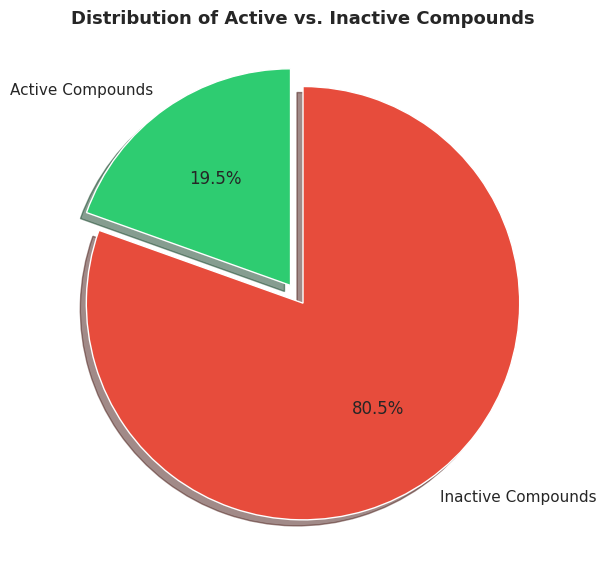

Active: 18,729 compounds (19.5%)
Inactive: 77,129 compounds (80.5%)


In [109]:
labels = ['Active Compounds', 'Inactive Compounds']

# Calculate actual sizes from df_clean
active_count = df_clean[df_clean['Activity_Outcome'] == 'Active'].shape[0]
inactive_count = df_clean[df_clean['Activity_Outcome'] == 'Inactive'].shape[0]
sizes = [active_count, inactive_count]

colors = ['#2ecc71', '#e74c3c']
explode = (0.1, 0)  # Slightly separate the 'Active' slice

fig, ax = plt.subplots(figsize=(8, 6))
ax.pie(sizes, explode=explode, labels=labels, colors=colors,
       autopct='%1.1f%%', shadow=True, startangle=90)

ax.set_title('Distribution of Active vs. Inactive Compounds', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Active: {sizes[0]:,} compounds ({sizes[0]/sum(sizes)*100:.1f}%)")
print(f"Inactive: {sizes[1]:,} compounds ({sizes[1]/sum(sizes)*100:.1f}%)")

Fix Class-Imbalance, Convert Inhibition At 5 uM to a more machine learning friendly standard, by classifying its related data to three distinct classes suitable for Machine learning regression models.

Aggregate Data

In [110]:
df_clean1 = (
    df_clean
    .groupby("SMILES", as_index=False)
    .agg({
        "PUBCHEM_CID": "first",
        "Inhibition_at_5_uM": "median",
        "Activity_Outcome": "first"
    })
)

print("Before aggregation:", df_clean.shape[0])
print("After aggregation:", df_clean1.shape[0])

df_clean1.head()

Before aggregation: 95858
After aggregation: 95858


,SMILES,PUBCHEM_CID,Inhibition_at_5_uM,Activity_Outcome
0,C#CC(CO)N(CCN(CC1=CC=CC=C1)C(CO)C#C)CC2=CC=CC=C2,2827417.0,94.6,Active
1,C#CC1=CC=C(C=C1)C(=O)NC2=C(C=CC(=C2)C(=O)N)N3C...,652860.0,16.1,Inactive
2,C#CCN1C(=C(N=C1S(=O)(=O)CC2=CC=C(C=C2)F)C3=CC=...,1476582.0,91.6,Active
3,C#CCN1C(=C(N=C1S(=O)(=O)CC2=CC=CC=C2Cl)C3=CC=C...,5187614.0,-4.6,Inactive
4,C#CCN1C2=CC=CC=C2C(C1=O)(CC(=O)C3=CC4=C(C=C3)O...,2939973.0,18.8,Inactive


In [111]:
df_clean1.Inhibition_at_5_uM.describe()

,Inhibition_at_5_uM
count,95858.000000
mean,18.373902
std,39.644176
min,-521.700000
25%,-1.600000
50%,13.700000
75%,40.800000
max,100.700000


### Categorical Classification of Activity

Classify the compounds into 'Active (Strong/Moderate)', 'Weak/Inactive', and 'Non-inhibitor' categories. This creates a categorical target variable suitable for classification-ML models.

In [112]:
# Define the categorization function
def classify_inhibition(inhibition_percentage):
    if inhibition_percentage >= 75:
        return 'Active (Strong/Moderate)'
    elif 25 <= inhibition_percentage < 75:
        return 'Weak/Inactive'
    else:
        return 'Non-inhibitor'

# Apply the function to create a new 'Activity_Class' column
df_clean1['Activity_Class'] = df_clean1['Inhibition_at_5_uM'].apply(classify_inhibition)

# Display the first few rows with the new column
display(df_clean1.head())

# Display the distribution of the new classes
print("\nDistribution of Activity Classes:")
display(df_clean1['Activity_Class'].value_counts())

,SMILES,PUBCHEM_CID,Inhibition_at_5_uM,Activity_Outcome,Activity_Class
0,C#CC(CO)N(CCN(CC1=CC=CC=C1)C(CO)C#C)CC2=CC=CC=C2,2827417.0,94.6,Active,Active (Strong/Moderate)
1,C#CC1=CC=C(C=C1)C(=O)NC2=C(C=CC(=C2)C(=O)N)N3C...,652860.0,16.1,Inactive,Non-inhibitor
2,C#CCN1C(=C(N=C1S(=O)(=O)CC2=CC=C(C=C2)F)C3=CC=...,1476582.0,91.6,Active,Active (Strong/Moderate)
3,C#CCN1C(=C(N=C1S(=O)(=O)CC2=CC=CC=C2Cl)C3=CC=C...,5187614.0,-4.6,Inactive,Non-inhibitor
4,C#CCN1C2=CC=CC=C2C(C1=O)(CC(=O)C3=CC4=C(C=C3)O...,2939973.0,18.8,Inactive,Non-inhibitor



Distribution of Activity Classes:


,count
Activity_Class,
Non-inhibitor,60094
Weak/Inactive,27740
Active (Strong/Moderate),8024


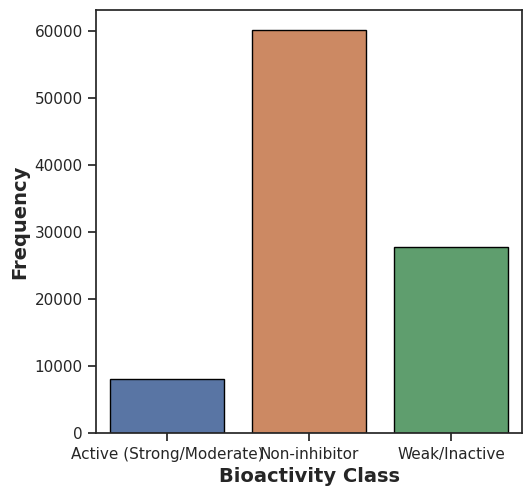

In [20]:
plt.figure(figsize=(5.5, 5.5))

sns.countplot(x="Activity_Class", data= df_clean1, hue="Activity_Class", edgecolor='black')

plt.xlabel('Bioactivity Class', fontsize=14, fontweight='bold')
plt.ylabel('Frequency', fontsize=14, fontweight='bold')
plt.show()

## Addressing Class Imbalance with Random Under-sampling

We will utilise **Random Under-sampling** function from the imblearn library. This will randomly remove samples from the majority classes until it matches majority class.

In [21]:
# Install imblearn if not already installed
!pip install imblearn

# Import RandomUnderSampler
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

Apply the Random sampling technique to our cleaned data. This will create a new DataFrame with a more even distribution across the categories.

In [113]:
# Separate features (X) and target (y)
X = df_clean1.drop('Activity_Class', axis=1)
y = df_clean1['Activity_Class']

print(f"Original class distribution: {Counter(y)}")

# Instantiate RandomUnderSampler
rus = RandomUnderSampler(random_state=42) # Using a random_state for reproducibility

# Resample the dataset
X_resampled, y_resampled = rus.fit_resample(X, y)

print(f"Resampled class distribution: {Counter(y_resampled)}")

# Reconstruct the balanced DataFrame
df_balanced = pd.concat([X_resampled, y_resampled], axis=1)

# Display the head of the new balanced DataFrame
display(df_balanced.head())

Original class distribution: Counter({'Non-inhibitor': 60094, 'Weak/Inactive': 27740, 'Active (Strong/Moderate)': 8024})
Resampled class distribution: Counter({'Active (Strong/Moderate)': 8024, 'Non-inhibitor': 8024, 'Weak/Inactive': 8024})


,SMILES,PUBCHEM_CID,Inhibition_at_5_uM,Activity_Outcome,Activity_Class
0,C#CC(CO)N(CCN(CC1=CC=CC=C1)C(CO)C#C)CC2=CC=CC=C2,2827417.0,94.6,Active,Active (Strong/Moderate)
2,C#CCN1C(=C(N=C1S(=O)(=O)CC2=CC=C(C=C2)F)C3=CC=...,1476582.0,91.6,Active,Active (Strong/Moderate)
23,C#CCSC1=NN=C(N1C2=CC=CC=C2)CSC3=NC4=CC=CC=C4S3,2132822.0,99.2,Active,Active (Strong/Moderate)
63,C/C(=C(/C#N)\C(=O)COC(=O)C1CCC(CC1)C(C)(C)C)/N,6380971.0,84.0,Active,Active (Strong/Moderate)
64,C/C(=C(/C#N)\C(=O)COC(=O)CC12CC3CC(C1)CC(C3)C2)/N,6051700.0,80.9,Active,Active (Strong/Moderate)


Let's visualize the new class distribution to confirm that the imbalance has been addressed.

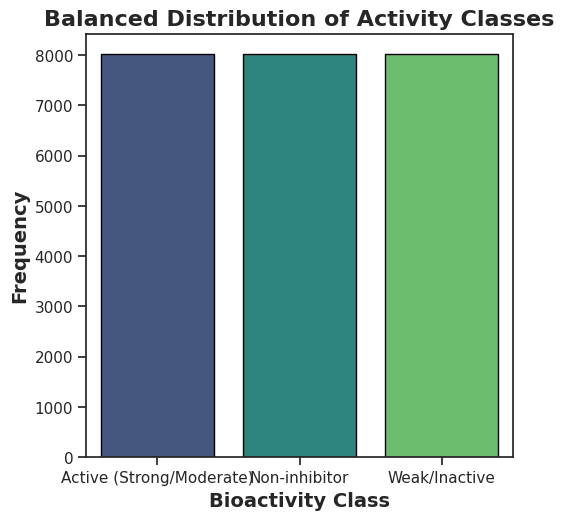

In [114]:
plt.figure(figsize=(5.5, 5.5))

sns.countplot(x="Activity_Class", data=df_balanced, hue="Activity_Class", edgecolor='black', palette='viridis')

plt.xlabel('Bioactivity Class', fontsize=14, fontweight='bold')
plt.ylabel('Frequency', fontsize=14, fontweight='bold')
plt.title('Balanced Distribution of Activity Classes', fontsize=16, fontweight='bold')
plt.show()

## Removing 'Weak/Inactive' Class for Binary Classification

Filter out the 'Weak/Inactive' class to create a dataset suitable for a binary classification task between 'Active (Strong/Moderate)' and 'Non-inhibitor' compounds. this will greatly optimise our pipeline, especially during fingerprint calculations.

In [115]:
# Filter df_balanced to exclude 'Weak/Inactive' compounds
df_binary_balanced = df_balanced[df_balanced['Activity_Class'].isin(['Active (Strong/Moderate)', 'Non-inhibitor'])]

print("Shape of DataFrame after removing 'Weak/Inactive' compounds:", df_binary_balanced.shape)

# Display the new class distribution
print("\nNew Distribution of Activity Classes (Binary):")
display(df_binary_balanced['Activity_Class'].value_counts())

display(df_binary_balanced.head())

Shape of DataFrame after removing 'Weak/Inactive' compounds: (16048, 5)

New Distribution of Activity Classes (Binary):


,count
Activity_Class,
Active (Strong/Moderate),8024
Non-inhibitor,8024


,SMILES,PUBCHEM_CID,Inhibition_at_5_uM,Activity_Outcome,Activity_Class
0,C#CC(CO)N(CCN(CC1=CC=CC=C1)C(CO)C#C)CC2=CC=CC=C2,2827417.0,94.6,Active,Active (Strong/Moderate)
2,C#CCN1C(=C(N=C1S(=O)(=O)CC2=CC=C(C=C2)F)C3=CC=...,1476582.0,91.6,Active,Active (Strong/Moderate)
23,C#CCSC1=NN=C(N1C2=CC=CC=C2)CSC3=NC4=CC=CC=C4S3,2132822.0,99.2,Active,Active (Strong/Moderate)
63,C/C(=C(/C#N)\C(=O)COC(=O)C1CCC(CC1)C(C)(C)C)/N,6380971.0,84.0,Active,Active (Strong/Moderate)
64,C/C(=C(/C#N)\C(=O)COC(=O)CC12CC3CC(C1)CC(C3)C2)/N,6051700.0,80.9,Active,Active (Strong/Moderate)



Now we fixed the class imbalance and produce a preliminary ready dataset for machine learning.

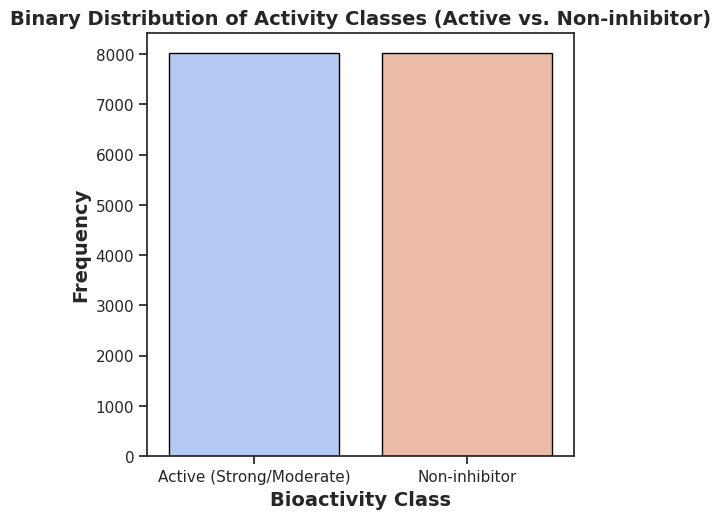

In [25]:
plt.figure(figsize=(5.5, 5.5))

sns.countplot(x="Activity_Class", data=df_binary_balanced, hue="Activity_Class", edgecolor='black', palette='coolwarm')

plt.xlabel('Bioactivity Class', fontsize=14, fontweight='bold')
plt.ylabel('Frequency', fontsize=14, fontweight='bold')
plt.title('Binary Distribution of Activity Classes (Active vs. Non-inhibitor)', fontsize=14, fontweight='bold')
plt.show()

Descriptors generation and Lipskins Rule of Fives

In [116]:
!pip install rdkit
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski
from rdkit.Chem import rdMolDescriptors

Always check what your dataset looks like before adding or removing information.

In [27]:
df_no_smiles = df_binary_balanced.drop(columns='SMILES')

smiles = []

for i in df_binary_balanced.SMILES.tolist():
  cpd = str(i).split('.')
  cpd_longest = max(cpd, key=len)
  smiles.append(cpd_longest)

smiles_series = pd.Series(smiles, name='SMILES', index=df_binary_balanced.index)

df_clean_smiles = pd.concat([df_no_smiles, smiles_series], axis=1)

df_clean_smiles.head()

,PUBCHEM_CID,Inhibition_at_5_uM,Activity_Outcome,Activity_Class,SMILES
0,2827417.0,94.6,Active,Active (Strong/Moderate),C#CC(CO)N(CCN(CC1=CC=CC=C1)C(CO)C#C)CC2=CC=CC=C2
2,1476582.0,91.6,Active,Active (Strong/Moderate),C#CCN1C(=C(N=C1S(=O)(=O)CC2=CC=C(C=C2)F)C3=CC=...
23,2132822.0,99.2,Active,Active (Strong/Moderate),C#CCSC1=NN=C(N1C2=CC=CC=C2)CSC3=NC4=CC=CC=C4S3
63,6380971.0,84.0,Active,Active (Strong/Moderate),C/C(=C(/C#N)\C(=O)COC(=O)C1CCC(CC1)C(C)(C)C)/N
64,6051700.0,80.9,Active,Active (Strong/Moderate),C/C(=C(/C#N)\C(=O)COC(=O)CC12CC3CC(C1)CC(C3)C2)/N


Create the function for Lipinski's rule of five, i reused my formula from my jak2qsar project

In [28]:
def lipinski(smiles, verbose=False):

    moldata= []
    for elem in smiles:
        mol=Chem.MolFromSmiles(elem)
        moldata.append(mol)

    baseData= np.arange(1,1)
    i=0
    for mol in moldata:

        desc_MolWt = Descriptors.MolWt(mol)
        desc_MolLogP = Descriptors.MolLogP(mol)
        desc_NumHDonors = Lipinski.NumHDonors(mol)
        desc_NumHAcceptors = Lipinski.NumHAcceptors(mol)

        row = np.array([desc_MolWt,
                        desc_MolLogP,
                        desc_NumHDonors,
                        desc_NumHAcceptors])

        if(i==0):
            baseData=row
        else:
            baseData=np.vstack([baseData, row])
        i=i+1

    columnNames=["MW","LogP","NumHDonors","NumHAcceptors"]
    descriptors = pd.DataFrame(data=baseData,columns=columnNames)

    return descriptors

In [29]:
df_lipinski = lipinski(df_clean_smiles.SMILES)
df_lipinski.head()

,MW,LogP,NumHDonors,NumHAcceptors
0,376.500,1.97900,2.0,4.0
1,430.504,4.96330,0.0,3.0
2,394.550,4.89460,0.0,6.0
3,306.406,2.70748,1.0,5.0
4,316.401,2.46148,1.0,5.0


In [30]:
df_lipinski.shape

(16048, 4)

Combine Both datasets

In [118]:
df_combined = pd.concat([df_clean_smiles.reset_index(drop=True), df_lipinski.reset_index(drop=True)], axis=1)
df_combined.head()

,PUBCHEM_CID,Inhibition_at_5_uM,Activity_Outcome,Activity_Class,SMILES,MW,LogP,NumHDonors,NumHAcceptors
0,2827417.0,94.6,Active,Active (Strong/Moderate),C#CC(CO)N(CCN(CC1=CC=CC=C1)C(CO)C#C)CC2=CC=CC=C2,376.500,1.97900,2.0,4.0
1,1476582.0,91.6,Active,Active (Strong/Moderate),C#CCN1C(=C(N=C1S(=O)(=O)CC2=CC=C(C=C2)F)C3=CC=...,430.504,4.96330,0.0,3.0
2,2132822.0,99.2,Active,Active (Strong/Moderate),C#CCSC1=NN=C(N1C2=CC=CC=C2)CSC3=NC4=CC=CC=C4S3,394.550,4.89460,0.0,6.0
3,6380971.0,84.0,Active,Active (Strong/Moderate),C/C(=C(/C#N)\C(=O)COC(=O)C1CCC(CC1)C(C)(C)C)/N,306.406,2.70748,1.0,5.0
4,6051700.0,80.9,Active,Active (Strong/Moderate),C/C(=C(/C#N)\C(=O)COC(=O)CC12CC3CC(C1)CC(C3)C2)/N,316.401,2.46148,1.0,5.0


Drop the Activity outcome column from the original Dataset AID:777, it wont be useful for machine learning or fingerprinting, always seeks to improve and optimise your code.

In [119]:
df_combined = df_combined.drop(columns="Activity_Outcome")
df_combined.head()

,PUBCHEM_CID,Inhibition_at_5_uM,Activity_Class,SMILES,MW,LogP,NumHDonors,NumHAcceptors
0,2827417.0,94.6,Active (Strong/Moderate),C#CC(CO)N(CCN(CC1=CC=CC=C1)C(CO)C#C)CC2=CC=CC=C2,376.500,1.97900,2.0,4.0
1,1476582.0,91.6,Active (Strong/Moderate),C#CCN1C(=C(N=C1S(=O)(=O)CC2=CC=C(C=C2)F)C3=CC=...,430.504,4.96330,0.0,3.0
2,2132822.0,99.2,Active (Strong/Moderate),C#CCSC1=NN=C(N1C2=CC=CC=C2)CSC3=NC4=CC=CC=C4S3,394.550,4.89460,0.0,6.0
3,6380971.0,84.0,Active (Strong/Moderate),C/C(=C(/C#N)\C(=O)COC(=O)C1CCC(CC1)C(C)(C)C)/N,306.406,2.70748,1.0,5.0
4,6051700.0,80.9,Active (Strong/Moderate),C/C(=C(/C#N)\C(=O)COC(=O)CC12CC3CC(C1)CC(C3)C2)/N,316.401,2.46148,1.0,5.0


In [33]:
df_combined.to_csv("df_lipinski.csv", index=False)

Barplot of the bioactivity classes

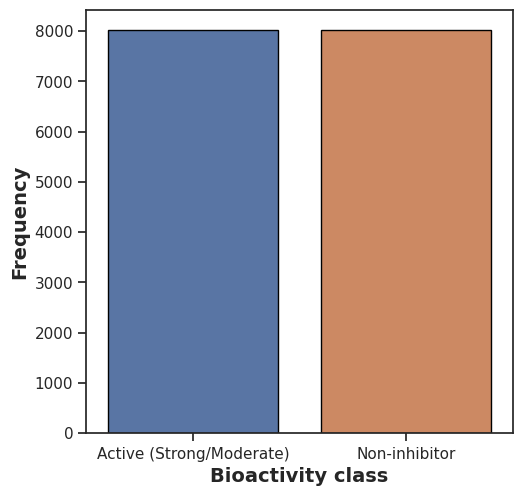

In [34]:
plt.figure(figsize=(5.5, 5.5))

sns.countplot(x="Activity_Class", data= df_combined, hue="Activity_Class", edgecolor='black')

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('Frequency', fontsize=14, fontweight='bold')

plt.savefig('barplot_bioactivity_class.pdf')

Boxplot of the bioactivity classes for Inhibition 5 uM

Text(0, 0.5, 'Inhibition at 5 uM value')

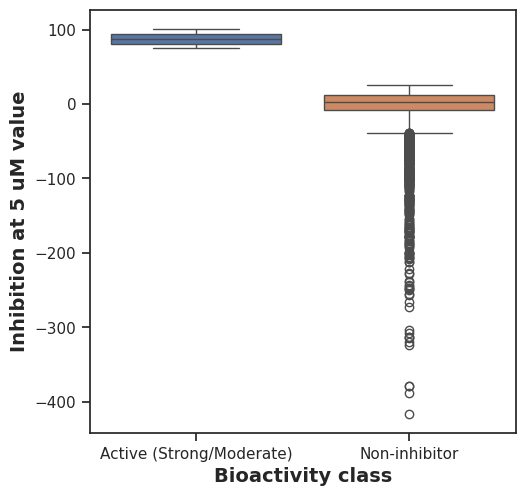

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = "Activity_Class", y = "Inhibition_at_5_uM", data = df_combined, hue="Activity_Class")

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('Inhibition at 5 uM value', fontsize=14, fontweight='bold')

Scatter of Molecular Weight vs Solubility (LogP)

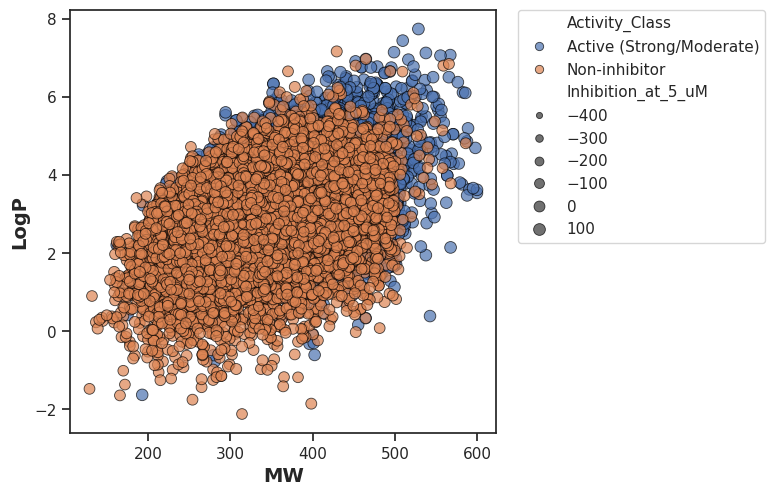

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df_combined_finite = df_combined[np.isfinite(df_combined['Inhibition_at_5_uM'])]

plt.figure(figsize=(5.5, 5.5))

sns.scatterplot(x='MW', y='LogP', data=df_combined_finite, hue='Activity_Class', size='Inhibition_at_5_uM', edgecolor='black', alpha=0.7)

plt.xlabel('MW', fontsize=14, fontweight='bold')
plt.ylabel('LogP', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0)
plt.savefig('scatter_plot_MW_vs_LogP.pdf')

Statistical analysis (Mann-Whitney U Test)

In [37]:
def mannwhitney(descriptor, df_combined, verbose=False):
    """
    Perform Mann-Whitney U test between active and non-inhibitor compounds
    for a given descriptor.

    Parameters:
    - descriptor : str, column name of the descriptor
    - df_combined : pandas DataFrame, must have columns [descriptor, Activity_Class]
    - verbose : bool, if True prints the test statistics

    Returns:
    - results : pandas DataFrame with test statistics, p-value, and interpretation
    """
    from numpy.random import seed
    from scipy.stats import mannwhitneyu
    import pandas as pd

    # set seed for reproducibility
    seed(1)

    # select only relevant columns, using 'Activity_Class'
    df = df_combined[[descriptor, 'Activity_Class']]

    # separate active and non-inhibitor compounds using correct labels
    active = df[df['Activity_Class'] == 'Active (Strong/Moderate)'][descriptor]
    non_inhibitor = df[df['Activity_Class'] == 'Non-inhibitor'][descriptor]

    # Drop any NaN values from the descriptor for the test
    active = active.dropna()
    non_inhibitor = non_inhibitor.dropna()

    # Ensure there are enough samples to perform the test
    if len(active) == 0 or len(non_inhibitor) == 0:
        print(f"Warning: Not enough data for descriptor '{descriptor}' to perform Mann-Whitney U test.")
        return pd.DataFrame({
            'Descriptor': descriptor,
            'Statistics': np.nan,
            'p': np.nan,
            'alpha': 0.05,
            'Interpretation': 'Not enough data'
        }, index=[0])

    # perform Mann-Whitney U test
    stat, p = mannwhitneyu(active, non_inhibitor)

    if verbose:
        print(f"Descriptor: {descriptor}")
        print(f"Statistics={stat:.3f}, p={p:.3f}")

    # interpret result
    alpha = 0.05
    if p > alpha:
        interpretation = 'Same distribution (fail to reject H0)'
    else:
        interpretation = 'Different distribution (reject H0)'

    # store results in a DataFrame
    results = pd.DataFrame({
        'Descriptor': descriptor,
        'Statistics': stat,
        'p': p,
        'alpha': alpha,
        'Interpretation': interpretation
    }, index=[0])

    # save results to CSV
    filename = 'mannwhitneyu_' + descriptor + '.csv'
    results.to_csv(filename, index=False)

    return results

inhibition 5 uM

In [120]:
mannwhitney("Inhibition_at_5_uM", df_combined, verbose=True)

Descriptor: Inhibition_at_5_uM
Statistics=64384576.000, p=0.000


,Descriptor,Statistics,p,alpha,Interpretation
0,Inhibition_at_5_uM,64384576.0,0.0,0.05,Different distribution (reject H0)


Molecular Weight

In [121]:
mannwhitney("MW", df_combined, verbose=True)

Descriptor: MW
Statistics=46504839.000, p=0.000


,Descriptor,Statistics,p,alpha,Interpretation
0,MW,46504839.0,0.0,0.05,Different distribution (reject H0)


Solubility LogP

In [122]:
mannwhitney("LogP", df_combined, verbose=True)

Descriptor: LogP
Statistics=46149190.000, p=0.000


,Descriptor,Statistics,p,alpha,Interpretation
0,LogP,46149190.0,0.0,0.05,Different distribution (reject H0)


Number of Hydrogen Donors

In [123]:
mannwhitney("NumHDonors", df_combined, verbose=True)

Descriptor: NumHDonors
Statistics=31794955.000, p=0.142


,Descriptor,Statistics,p,alpha,Interpretation
0,NumHDonors,31794955.0,0.142216,0.05,Same distribution (fail to reject H0)


Number of Hydrogen Acceptors

In [124]:
mannwhitney("NumHAcceptors", df_combined, verbose=True)

Descriptor: NumHAcceptors
Statistics=39876631.500, p=0.000


,Descriptor,Statistics,p,alpha,Interpretation
0,NumHAcceptors,39876631.5,2.354215e-156,0.05,Different distribution (reject H0)


Combine All Statistical Results

In [125]:
import pandas as pd
import glob
import os

# Get list of all Mann-Whitney CSV files in current folder
mw_files = glob.glob("mannwhitneyu_*.csv")

# Combine them into one DataFrame
mw_combined = pd.concat([pd.read_csv(f) for f in mw_files], ignore_index=True)

# Save combined CSV
combined_filename = "mannwhitney_summary.csv"
mw_combined.to_csv(combined_filename, index=False)

print(f"Combined Mann-Whitney CSV saved as {combined_filename}")

Combined Mann-Whitney CSV saved as mannwhitney_summary.csv


In [126]:
mw_combined

,Descriptor,Statistics,p,alpha,Interpretation
0,Inhibition_at_5_uM,64384576.0,0.000000e+00,0.05,Different distribution (reject H0)
1,MW,46504839.0,0.000000e+00,0.05,Different distribution (reject H0)
2,NumHAcceptors,39876631.5,2.354215e-156,0.05,Different distribution (reject H0)
3,LogP,46149190.0,0.000000e+00,0.05,Different distribution (reject H0)
4,NumHDonors,31794955.0,1.422164e-01,0.05,Same distribution (fail to reject H0)


Molecular Weight

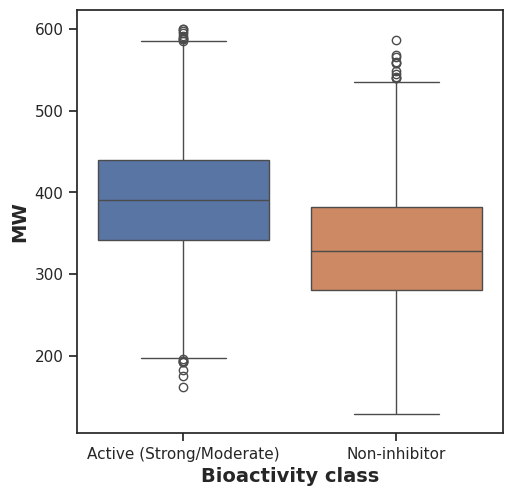

In [127]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'Activity_Class', y = 'MW', data = df_combined, hue="Activity_Class")

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('MW', fontsize=14, fontweight='bold')

plt.savefig('boxplot_MW.pdf')

logP

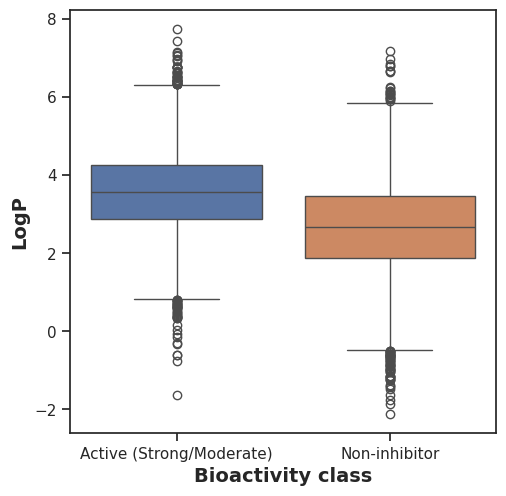

In [128]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = "Activity_Class", y = 'LogP', data = df_combined, hue="Activity_Class")

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('LogP', fontsize=14, fontweight='bold')

plt.savefig('boxplot_LogP.pdf')

NumHDonors

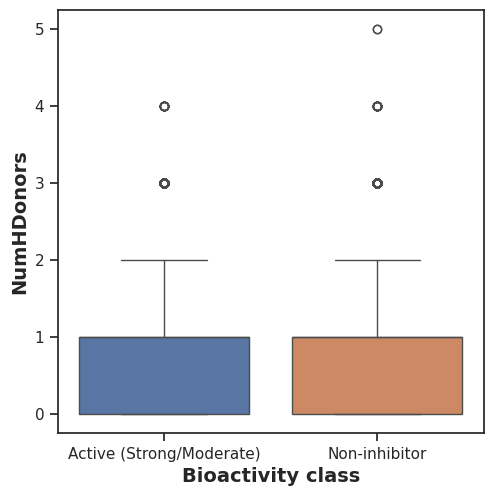

In [129]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = "Activity_Class", y = "NumHDonors", data = df_combined, hue="Activity_Class")

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('NumHDonors', fontsize=14, fontweight='bold')

plt.savefig('boxplot_NumHDonors.pdf')

NumHAcceptors


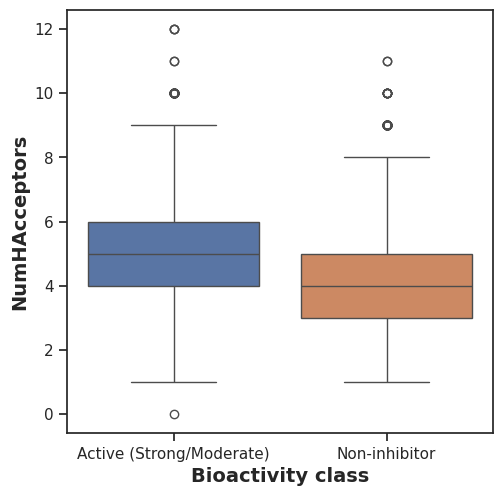

In [130]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = "Activity_Class", y = "NumHAcceptors", data = df_combined, hue="Activity_Class")

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('NumHAcceptors', fontsize=14, fontweight='bold')

plt.savefig('boxplot_NumHAcceptors.pdf')

In [49]:
! zip -r EDA_results.zip . -i *df_lipinski.csv *mannwhitney_summary.csv *.pdf

  adding: boxplot_MW.pdf (deflated 37%)
  adding: boxplot_NumHAcceptors.pdf (deflated 37%)
  adding: barplot_bioactivity_class.pdf (deflated 36%)
  adding: boxplot_LogP.pdf (deflated 34%)
  adding: boxplot_NumHDonors.pdf (deflated 37%)
  adding: mannwhitney_summary.csv (deflated 49%)
  adding: scatter_plot_MW_vs_LogP.pdf (deflated 2%)
  adding: df_lipinski.csv (deflated 75%)


Descriptor Calculation

In [50]:
!pip install padelpy

import pandas as pd
import numpy as np
from google.colab import files
from padelpy import padeldescriptor

df = pd.read_csv('df_lipinski.csv')
df.head()

,PUBCHEM_CID,Inhibition_at_5_uM,Activity_Class,SMILES,MW,LogP,NumHDonors,NumHAcceptors
0,2827417.0,94.6,Active (Strong/Moderate),C#CC(CO)N(CCN(CC1=CC=CC=C1)C(CO)C#C)CC2=CC=CC=C2,376.500,1.97900,2.0,4.0
1,1476582.0,91.6,Active (Strong/Moderate),C#CCN1C(=C(N=C1S(=O)(=O)CC2=CC=C(C=C2)F)C3=CC=...,430.504,4.96330,0.0,3.0
2,2132822.0,99.2,Active (Strong/Moderate),C#CCSC1=NN=C(N1C2=CC=CC=C2)CSC3=NC4=CC=CC=C4S3,394.550,4.89460,0.0,6.0
3,6380971.0,84.0,Active (Strong/Moderate),C/C(=C(/C#N)\C(=O)COC(=O)C1CCC(CC1)C(C)(C)C)/N,306.406,2.70748,1.0,5.0
4,6051700.0,80.9,Active (Strong/Moderate),C/C(=C(/C#N)\C(=O)COC(=O)CC12CC3CC(C1)CC(C3)C2)/N,316.401,2.46148,1.0,5.0


In [51]:
data = df[['SMILES', 'PUBCHEM_CID']]
data.head()

,SMILES,PUBCHEM_CID
0,C#CC(CO)N(CCN(CC1=CC=CC=C1)C(CO)C#C)CC2=CC=CC=C2,2827417.0
1,C#CCN1C(=C(N=C1S(=O)(=O)CC2=CC=C(C=C2)F)C3=CC=...,1476582.0
2,C#CCSC1=NN=C(N1C2=CC=CC=C2)CSC3=NC4=CC=CC=C4S3,2132822.0
3,C/C(=C(/C#N)\C(=O)COC(=O)C1CCC(CC1)C(C)(C)C)/N,6380971.0
4,C/C(=C(/C#N)\C(=O)COC(=O)CC12CC3CC(C1)CC(C3)C2)/N,6051700.0


Convert to .smi format

In [52]:
df_smi = data['SMILES'].to_csv('smiles_chembl.smi', index=None, header=None)

In [53]:
! cat smiles_chembl.smi | head

C#CC(CO)N(CCN(CC1=CC=CC=C1)C(CO)C#C)CC2=CC=CC=C2
C#CCN1C(=C(N=C1S(=O)(=O)CC2=CC=C(C=C2)F)C3=CC=CC=C3)C4=CC=CC=C4
C#CCSC1=NN=C(N1C2=CC=CC=C2)CSC3=NC4=CC=CC=C4S3
C/C(=C(/C#N)\C(=O)COC(=O)C1CCC(CC1)C(C)(C)C)/N
C/C(=C(/C#N)\C(=O)COC(=O)CC12CC3CC(C1)CC(C3)C2)/N
C/C(=C(/C#N)\C(=O)CSC1=NN(C(=N1)C2CCCCC2)C3=CC=CC=C3)/N
C/C(=C/CN1C2=C(N=C1NCCCN3C=CN=C3)N(C(=O)NC2=O)C)/Cl
C/C(=C/CSC1=NN2C(=O)C3=CC=CC=C3N=C2S1)/Cl
C/C(=C\C1=CC=CC=C1)/C=N/NC(=O)C2=CC=NC=C2
C/C(=C\C1=CC=CO1)/C2C(=C(OC3=C2C(=O)CC(C3)(C)C)N)C#N


Calculate molecular Pubchem Fingerprints using "padeldescriptor" function

In [54]:
padeldescriptor(mol_dir= "smiles_chembl.smi",
                d_file='pubchem_fingerprints.csv',
                fingerprints = True,
                retainorder= True,
                #removesalt = True, standardizetautomers = True, standardizenitro=True
                )

In [55]:
!ls -lh pubchem_fingerprints.csv

-rw-r--r-- 1 root root 28M May 13 22:16 pubchem_fingerprints.csv


In [56]:
df_fingerprint = pd.read_csv("pubchem_fingerprints.csv")
df_fingerprint.head()

,Name,PubchemFP0,PubchemFP1,PubchemFP2,PubchemFP3,PubchemFP4,PubchemFP5,PubchemFP6,PubchemFP7,PubchemFP8,...,PubchemFP871,PubchemFP872,PubchemFP873,PubchemFP874,PubchemFP875,PubchemFP876,PubchemFP877,PubchemFP878,PubchemFP879,PubchemFP880
0,AUTOGEN_smiles_chembl_1,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,AUTOGEN_smiles_chembl_2,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,AUTOGEN_smiles_chembl_3,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,AUTOGEN_smiles_chembl_4,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,AUTOGEN_smiles_chembl_5,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## 3. Prepare Dataset for ML

In [57]:
# Select only the columns we need for ML
meta_cols = df[['PUBCHEM_CID', 'Activity_Class', 'Inhibition_at_5_uM']]

# Reset index to ensure proper alignment
meta_cols = meta_cols.reset_index(drop=True)
df_fingerprint = df_fingerprint.reset_index(drop=True)

# Combine meta data with fingerprints
combined_df = pd.concat([meta_cols, df_fingerprint.drop(df_fingerprint.columns[0], axis=1)], axis=1)

# Inspect the first few rows
combined_df.head()

,PUBCHEM_CID,Activity_Class,Inhibition_at_5_uM,PubchemFP0,PubchemFP1,PubchemFP2,PubchemFP3,PubchemFP4,PubchemFP5,PubchemFP6,...,PubchemFP871,PubchemFP872,PubchemFP873,PubchemFP874,PubchemFP875,PubchemFP876,PubchemFP877,PubchemFP878,PubchemFP879,PubchemFP880
0,2827417.0,Active (Strong/Moderate),94.6,1,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1476582.0,Active (Strong/Moderate),91.6,1,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2132822.0,Active (Strong/Moderate),99.2,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,6380971.0,Active (Strong/Moderate),84.0,1,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,6051700.0,Active (Strong/Moderate),80.9,1,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Calculate other fingerprints
Download xml Files from Github

In [58]:
!wget https://github.com/AI-Biotechnology-Bioinformatics/Drug_Discovery_AI_Course_2026/raw/main/padel_descriptors_xml.zip

!unzip padel_descriptors_xml.zip

--2026-05-13 22:16:36--  https://github.com/AI-Biotechnology-Bioinformatics/Drug_Discovery_AI_Course_2026/raw/main/padel_descriptors_xml.zip
Resolving github.com (github.com)... 140.82.112.4
Connecting to github.com (github.com)|140.82.112.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/AI-Biotechnology-Bioinformatics/Drug_Discovery_AI_Course_2026/main/padel_descriptors_xml.zip [following]
--2026-05-13 22:16:37--  https://raw.githubusercontent.com/AI-Biotechnology-Bioinformatics/Drug_Discovery_AI_Course_2026/main/padel_descriptors_xml.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10871 (11K) [application/zip]
Saving to: ‘padel_descriptors_xml.zip’

padel_descriptors_x 100%[=============

In [59]:
#Calculate Fingerprints
# Specify the XML file for SubstructureFingerprinter directly
Substruc_fp = "SubstructureFingerprinter.xml"

# Calculate Substructure fingerprints, (extra-part)
padeldescriptor(
    mol_dir='smiles_chembl.smi',
    d_file='Substructure_fingerprints.csv',
    fingerprints=True,
    descriptortypes= Substruc_fp,
    retainorder=True
    # removesalt=True, standardizetautomers=True
)

In [60]:
# Install LazyPredict
!pip install lazypredict
# Install SHAP
!pip install shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import train_test_split, cross_val_score

# The 5 models from the DengueDrug project
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

# Evaluation metrics
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                              recall_score, classification_report, confusion_matrix)

Features (X) and Target (y)

In [61]:
import pandas as pd

# Reload the cleaned and combined data to ensure we are using the correct DataFrame
df = pd.read_csv('df_lipinski.csv')

# Exclude non-feature columns
non_feature_cols = ['PUBCHEM_CID', 'SMILES', 'Activity_Class', 'Inhibition_at_5_uM']
X = df.drop(columns=non_feature_cols)
print(X.shape)

(16048, 4)


In [62]:
# Target variable
y_reg = df['Activity_Class']
y_reg

,Activity_Class
0,Active (Strong/Moderate)
1,Active (Strong/Moderate)
2,Active (Strong/Moderate)
3,Active (Strong/Moderate)
4,Active (Strong/Moderate)
...,...
16043,Non-inhibitor
16044,Non-inhibitor
16045,Non-inhibitor
16046,Non-inhibitor


In [63]:
from sklearn.feature_selection import VarianceThreshold

# Apply variance threshold
selection = VarianceThreshold(threshold=(0.8*(1-0.8)))  # Threshold = 0.16
X_var = selection.fit_transform(X)

# Extract the correct feature names
selected_mask = selection.get_support()
feature_names = X.columns[selected_mask]

# Convert immediately to DataFrame
X_var = pd.DataFrame(X_var, columns=feature_names)

print('After variance threshold:', X_var.shape)

After variance threshold: (16048, 4)


Split Data into Training and Test Set

In [64]:
from sklearn.model_selection import train_test_split

# Split into 80/20 train/test
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_var, y_reg, test_size=0.2, random_state=123
)
print(f'Training set size: {X_train_reg.shape[0]} molecules')
print(f'Testing set size: {X_test_reg.shape[0]} molecules')

Training set size: 12838 molecules
Testing set size: 3210 molecules


Build and Train Models, use standardscaler to optimise your ML models

In [92]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.preprocessing import StandardScaler # Ensure StandardScaler is imported

# Initialize StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and test data
X_train_reg = pd.DataFrame(scaler.fit_transform(X_train_reg), columns=X_train_reg.columns, index=X_train_reg.index)
X_test_reg = pd.DataFrame(scaler.transform(X_test_reg), columns=X_test_reg.columns, index=X_test_reg.index)

# Define all 5 models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "SVM":                 SVC(kernel='rbf', random_state=42),
    "K-Nearest Neighbours": KNeighborsClassifier(n_neighbors=5),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42),
    "Naive Bayes":         GaussianNB()
}

# Train and evaluate each model
results = {}

print(f"{'Model':<25} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("-" * 70)

for name, model in models.items():
    # Train
    model.fit(X_train_reg, y_train_reg)

    # Predict on test set
    y_pred = model.predict(X_test_reg)

    # Calculate metrics
    # Explicitly set pos_label to the string representing the positive class
    acc  = accuracy_score(y_test_reg, y_pred)
    prec = precision_score(y_test_reg, y_pred, pos_label='Active (Strong/Moderate)', zero_division=0)
    rec  = recall_score(y_test_reg, y_pred, pos_label='Active (Strong/Moderate)', zero_division=0)
    f1   = f1_score(y_test_reg, y_pred, pos_label='Active (Strong/Moderate)', zero_division=0)

    results[name] = {"Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1}
    print(f"{name:<25} {acc:>10.3f} {prec:>10.3f} {rec:>10.3f} {f1:>10.3f}")

Model                       Accuracy  Precision     Recall         F1
----------------------------------------------------------------------
Logistic Regression            0.711      0.708      0.712      0.710
SVM                            0.716      0.692      0.772      0.730
K-Nearest Neighbours           0.681      0.672      0.699      0.686
Random Forest                  0.687      0.671      0.724      0.697
Naive Bayes                    0.710      0.699      0.733      0.715


Evaluation Metrics, measure the four parameters to assess model reliability

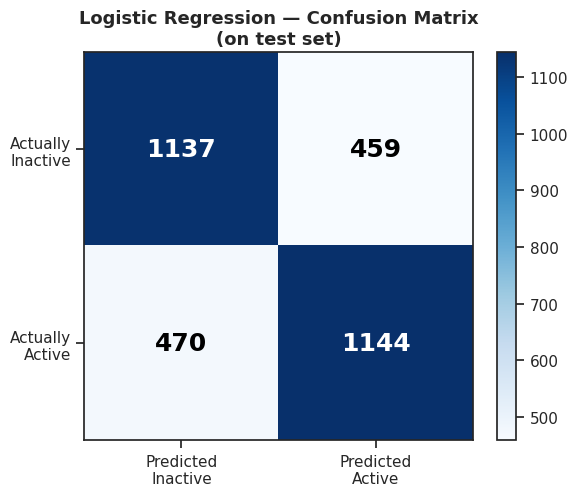

True Positives  (correctly identified actives):   1144
True Negatives  (correctly identified inactives): 1137
False Positives (inactives called active):        459  ← Wastes lab resources
False Negatives (actives called inactive):        470  ← Misses drug candidates!


In [70]:
# Look at the confusion matrix for Logistic Regression
lr_model = models["Logistic Regression"]
y_pred_lr = lr_model.predict(X_test_reg)

cm = confusion_matrix(y_test_reg, y_pred_lr)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')

# Labels
ax.set_xticks([0, 1]); ax.set_xticklabels(['Predicted\nInactive', 'Predicted\nActive'], fontsize=11)
ax.set_yticks([0, 1]); ax.set_yticklabels(['Actually\nInactive', 'Actually\nActive'], fontsize=11)

# Add values
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=18, fontweight='bold',
                color='white' if cm[i, j] > cm.max()/2 else 'black')

ax.set_title('Logistic Regression — Confusion Matrix\n(on test set)', fontsize=13, fontweight='bold')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Positives  (correctly identified actives):   {tp}")
print(f"True Negatives  (correctly identified inactives): {tn}")
print(f"False Positives (inactives called active):        {fp}  ← Wastes lab resources")
print(f"False Negatives (actives called inactive):        {fn}  ← Misses drug candidates!")

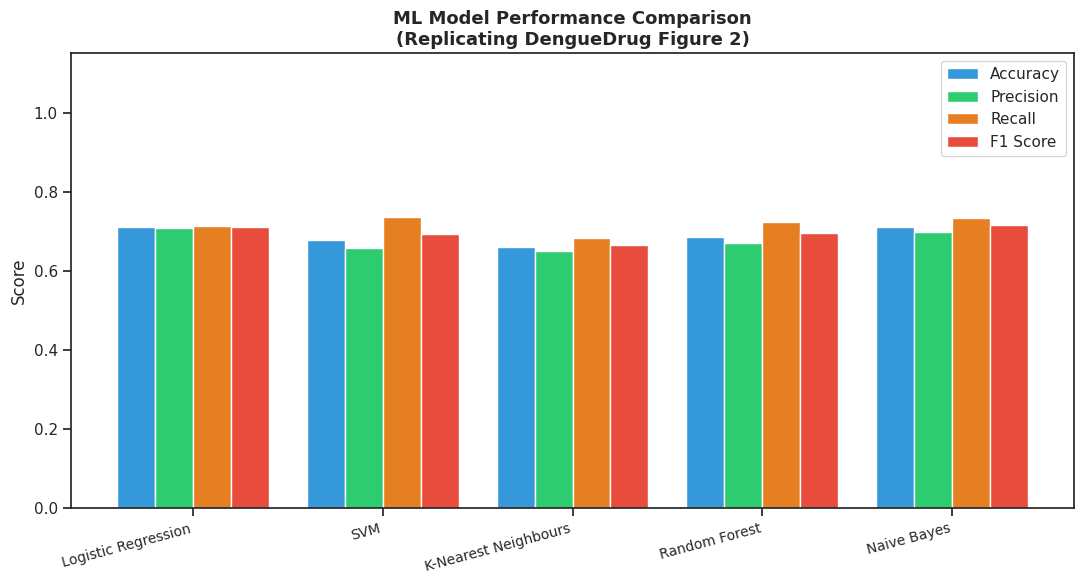

In [71]:
results_df = pd.DataFrame(results).T

x = np.arange(len(results_df))
width = 0.2

fig, ax = plt.subplots(figsize=(11, 6))

b1 = ax.bar(x - 1.5*width, results_df['Accuracy'],  width, label='Accuracy',  color='#3498db')
b2 = ax.bar(x - 0.5*width, results_df['Precision'], width, label='Precision', color='#2ecc71')
b3 = ax.bar(x + 0.5*width, results_df['Recall'],    width, label='Recall',    color='#e67e22')
b4 = ax.bar(x + 1.5*width, results_df['F1'],        width, label='F1 Score',  color='#e74c3c')

ax.set_xticks(x)
ax.set_xticklabels(results_df.index, rotation=15, ha='right', fontsize=10)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0, 1.15)
ax.set_title('ML Model Performance Comparison\n(Replicating DengueDrug Figure 2)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

Cross-Validation - Robust Evaluation

In [79]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import make_scorer, f1_score

# Define a custom scorer for F1 that specifies the positive label
f1_scorer = make_scorer(f1_score, pos_label='Active (Strong/Moderate)', zero_division=0)

# Use 5-fold cross-validation on Logistic Regression (the best model)
lr = LogisticRegression(max_iter=1000, random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(lr, X_train_reg, y_train_reg, cv=cv, scoring=f1_scorer)

print("Logistic Regression — 5-Fold Cross-Validation F1 Scores:")
for i, score in enumerate(cv_scores):
    print(f"  Fold {i+1}: {score:.3f}")
print(f"\n  Mean: {cv_scores.mean():.3f}")
print(f"  Std:  {cv_scores.std():.3f}")
print("\nLow std = stable model — consistent across different data subsets.")

Logistic Regression — 5-Fold Cross-Validation F1 Scores:
  Fold 1: 0.705
  Fold 2: 0.674
  Fold 3: 0.692
  Fold 4: 0.716
  Fold 5: 0.691

  Mean: 0.695
  Std:  0.014

Low std = stable model — consistent across different data subsets.


Use LazyPredict to further validate your forest regression model on test data, testing only 1 model out of the 5. (common for QSAR)

In [132]:
rf_model = models["Random Forest"]

# For a classification model, .score() returns the accuracy
accuracy = rf_model.score(X_test_reg, y_test_reg)
print(f'Random Forest Accuracy score: {accuracy:.4f}')

Random Forest Accuracy score: 0.6866


Y-Randomization - Validate Model

In [134]:
from sklearn.utils import shuffle
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

n_iterations = 5
random_accuracy_scores = [] # Changed variable name for clarity

# The target variables (y_train_reg, y_test_reg) contain string labels
# and do not have 'infinite' values, so np.isfinite() is not applicable.
# We will use the original X_train_reg, X_test_reg, y_train_reg, y_test_reg directly.

for i in range(n_iterations):
    # Shuffle only the target labels for Y-randomization
    y_train_shuffled = shuffle(y_train_reg, random_state=i)

    # Use RandomForestClassifier for classification task
    rf_random = RandomForestClassifier(n_estimators=200, random_state=42)
    rf_random.fit(X_train_reg, y_train_shuffled)

    y_pred_random = rf_random.predict(X_test_reg)

    # Calculate accuracy for classification models
    accuracy_random = accuracy_score(y_test_reg, y_pred_random)
    random_accuracy_scores.append(accuracy_random)

print('\nY-Randomization Test Results (Classification Accuracy):')
print(f'Mean Accuracy with shuffled Y: {np.mean(random_accuracy_scores):.4f}')

# 'accuracy' was calculated in the previous cell VfSa2veKpK29 for the actual RF model
print(f'Actual RF Accuracy: {accuracy:.4f}')


Y-Randomization Test Results (Classification Accuracy):
Mean Accuracy with shuffled Y: 0.5062
Actual RF Accuracy: 0.6866


Notes: The mean accuracy with shuffled Y is 0.5062, which is lower than the actual Random Forest accuracy of 0.6866. This suggests that the model is learning meaningful patterns from the true labels, as expected.

## 4. Feature Importance

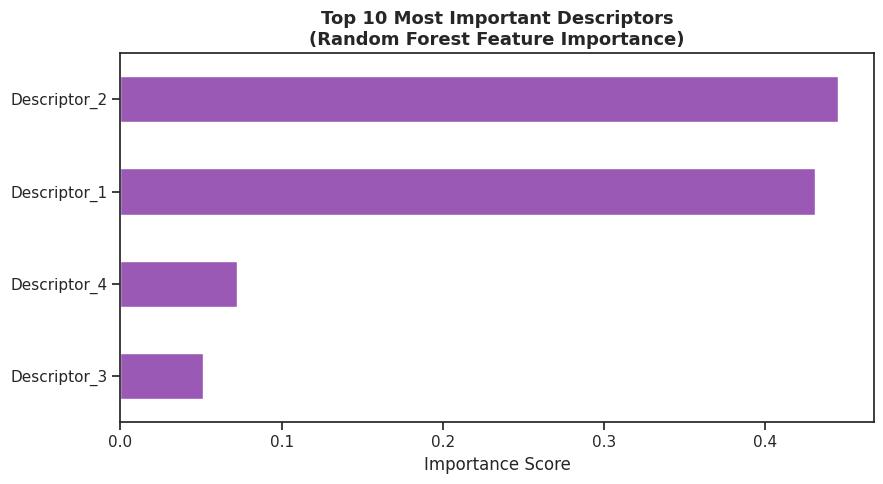

In [78]:
rf_model = models["Random Forest"]
feature_names = [f"Descriptor_{i+1}" for i in range(X_train_reg.shape[1])]

# Get importances
importances = pd.Series(rf_model.feature_importances_, index=feature_names)
top10 = importances.nlargest(10)

fig, ax = plt.subplots(figsize=(9, 5))
top10.sort_values().plot(kind='barh', ax=ax, color='#9b59b6')
ax.set_title('Top 10 Most Important Descriptors\n(Random Forest Feature Importance)', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score', fontsize=12)
plt.tight_layout()
plt.show()


Next Part, we will save the best model, remove the models from memory, load it and test our model on known inhibitors, then use our model to screen large datasets of natural compounds to find new/novel CYP2C9 inhibitors